# CELL 1 — Mount Google Drive

In [17]:
# ============================================================
# EXPERIMENTAL PROTOCOL FREEZE
# CELL 1
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


print("="*70)
print("GOOGLE DRIVE BERHASIL TERHUBUNG")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GOOGLE DRIVE BERHASIL TERHUBUNG


# CELL 2 — Clone Repository GitHub

In [18]:
# ============================================================
# CELL 2
# Clone / Update Repository
# ============================================================


import os
import subprocess


REPO_PATH = "/content/label-noise-thesis"

GITHUB_URL = (
    "https://github.com/"
    "luthfiaw13/label-noise-thesis.git"
)


if not os.path.exists(REPO_PATH):

    print("Repository belum ada.")
    print("Melakukan clone...")


    subprocess.run(
        [
            "git",
            "clone",
            GITHUB_URL,
            REPO_PATH
        ],
        check=True
    )

else:

    print("Repository sudah tersedia.")

    subprocess.run(
        [
            "git",
            "-C",
            REPO_PATH,
            "status"
        ]
    )


print()
print("="*70)
print("REPOSITORY SIAP")
print("="*70)

Repository sudah tersedia.

REPOSITORY SIAP


# CELL 3 — Import Library

In [19]:
# ============================================================
# CELL 3
# Import Library
# ============================================================


from pathlib import Path
import json
import yaml
import torch
import pandas as pd
import matplotlib.pyplot as plt


print("="*70)
print("LIBRARY BERHASIL DIMUAT")
print("="*70)

LIBRARY BERHASIL DIMUAT


In [20]:
# ============================================================
# CELL 4
# Validasi Struktur Repository
# ============================================================


REQUIRED_DIR = [

    "src",
    "src/data",
    "src/models",
    "src/training",
    "src/evaluation",

    "manifests",

]


print("="*70)
print("VALIDASI STRUKTUR PROJECT")
print("="*70)


for folder in REQUIRED_DIR:

    path = Path(REPO_PATH) / folder

    if path.exists():

        print(f"✅ {folder}")

    else:

        print(f"❌ {folder} tidak ditemukan")


print()

VALIDASI STRUKTUR PROJECT
✅ src
✅ src/data
✅ src/models
✅ src/training
✅ src/evaluation
✅ manifests



In [21]:
# ============================================================
# CELL 5
# Output Directory
# ============================================================


DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/"
    "skripsi_label_noise"
)


CONFIG_DIR = DRIVE_PROJECT / "configs_snapshot"

OUTPUT_DIR = (
    DRIVE_PROJECT /
    "outputs" /
    "protocol_freeze"
)


CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Direktori output siap.")

Direktori output siap.


In [22]:
# ============================================================
# CELL 6
# Dataset Configuration
# ============================================================


dataset_config = {

    "synthetic_noise_experiment": {

        "dataset":
        "CIFAR-10",

        "noise_protocol":
        [
            "Symmetric Class-Balanced Corruption",
            "Asymmetric Pair-Flip Class-Balanced Corruption"
        ]

    },


    "human_noise_validation": {

        "dataset":
        "CIFAR-10N",

        "usage":
        "Real Human Annotation Noise Validation"

    }

}



print(
    json.dumps(
        dataset_config,
        indent=4
    )
)

{
    "synthetic_noise_experiment": {
        "dataset": "CIFAR-10",
        "noise_protocol": [
            "Symmetric Class-Balanced Corruption",
            "Asymmetric Pair-Flip Class-Balanced Corruption"
        ]
    },
    "human_noise_validation": {
        "dataset": "CIFAR-10N",
        "usage": "Real Human Annotation Noise Validation"
    }
}


In [23]:
# ============================================================
# CELL 7
# Model Configuration
# ============================================================


model_config = {


    "models":

    [

        "ResNet18",

        "ResNet34",

        "ResNet50"

    ],


    "input_size":

    "32x32",


    "classes":

    10,


    "architecture":

    "CIFAR-compatible ResNet"


}


print(
    json.dumps(
        model_config,
        indent=4
    )
)

{
    "models": [
        "ResNet18",
        "ResNet34",
        "ResNet50"
    ],
    "input_size": "32x32",
    "classes": 10,
    "architecture": "CIFAR-compatible ResNet"
}


In [24]:
# ============================================================
# CELL 8
# Training Configuration
# ============================================================


training_config = {


    "optimizer":

    "SGD",


    "learning_rate":

    0.1,


    "momentum":

    0.9,


    "weight_decay":

    0.0005,


    "scheduler":

    "Warmup + Cosine Annealing",


    "batch_size":

    256,


    "mixed_precision":

    True,


    "seed":

    17


}



print(
    json.dumps(
        training_config,
        indent=4
    )
)

{
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "scheduler": "Warmup + Cosine Annealing",
    "batch_size": 256,
    "mixed_precision": true,
    "seed": 17
}


In [25]:
# ============================================================
# CELL 9
# Evaluation Configuration
# ============================================================


evaluation_config = {


    "metrics":

    [
    "Accuracy",
    "Precision",
    "Recall",
    "Macro F1",
    "Loss",
    "Confusion Matrix",
    "Kappa Coefficient"
    ],


    "validation":

    "Validation split only",


    "test_usage":

    "Only final evaluation"

}



print(
    json.dumps(
        evaluation_config,
        indent=4
    )
)

{
    "metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1",
        "Loss",
        "Confusion Matrix",
        "Kappa Coefficient"
    ],
    "validation": "Validation split only",
    "test_usage": "Only final evaluation"
}


In [26]:
# ============================================================
# CELL 10
# Save Configuration
# ============================================================


configs = {


    "dataset":
    dataset_config,


    "model":
    model_config,


    "training":
    training_config,


    "evaluation":
    evaluation_config

}



config_file = (
    CONFIG_DIR /
    "experimental_protocol_freeze.json"
)


with open(
    config_file,
    "w"
) as f:


    json.dump(
        configs,
        f,
        indent=4
    )


print(
    "✅ Configuration tersimpan:"
)

print(config_file)

✅ Configuration tersimpan:
/content/drive/MyDrive/skripsi_label_noise/configs_snapshot/experimental_protocol_freeze.json


In [31]:
# ============================================================
# CELL 11
# Protocol Manifest
# ============================================================


manifest = {


    "phase":

    "Experimental Protocol Freeze",


    "status":

    "FROZEN",


    "dataset_protocol": {


        "synthetic_noise_experiment":

        "CIFAR-10",


        "human_noise_validation":

        "CIFAR-10N"

    },


    "models":

    [

        "ResNet18",

        "ResNet34",

        "ResNet50"

    ],


    "seed":

    17,


    "reproducible":

    True

}



manifest_file = (
    OUTPUT_DIR /
    "protocol_report.json"
)


with open(
    manifest_file,
    "w"
) as f:


    json.dump(
        manifest,
        f,
        indent=4
    )


print(
    "✅ Protocol manifest tersimpan"
)

✅ Protocol manifest tersimpan


,Komponen,Nilai
0,Dataset,CIFAR-10 + CIFAR-10N
1,Jumlah Data Train,50.000
2,Jumlah Kelas,10
3,Input Image,32x32
4,Model,ResNet18 / ResNet34 / ResNet50
5,Optimizer,SGD
6,Learning Rate,0.1
7,Momentum,0.9
8,Weight Decay,0.0005
9,Scheduler,Warmup + Cosine Annealing


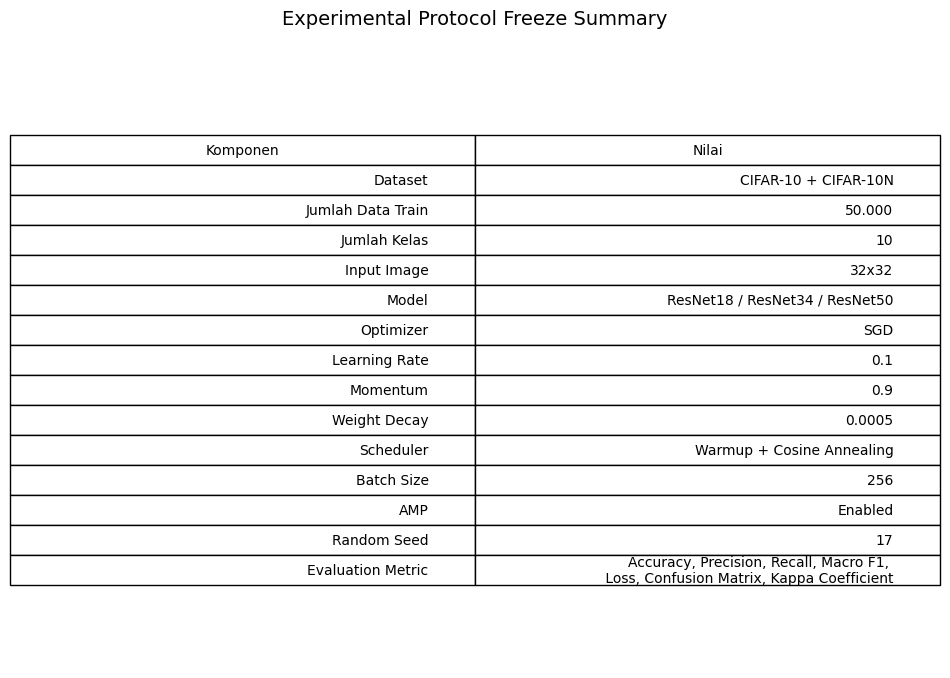


PROTOCOL SUMMARY FINAL

CSV tersimpan:
/content/drive/MyDrive/skripsi_label_noise/outputs/protocol_freeze/experimental_protocol_summary.csv

Visualisasi tersimpan:
/content/drive/MyDrive/skripsi_label_noise/outputs/protocol_freeze/experimental_protocol_summary.png


In [32]:
# ============================================================
# CELL 12
# Experimental Protocol Freeze Visualization (FINAL)
# ============================================================


import pandas as pd
import matplotlib.pyplot as plt


protocol_summary = pd.DataFrame(

    {

        "Komponen":

        [

            "Dataset",

            "Jumlah Data Train",

            "Jumlah Kelas",

            "Input Image",

            "Model",

            "Optimizer",

            "Learning Rate",

            "Momentum",

            "Weight Decay",

            "Scheduler",

            "Batch Size",

            "AMP",

            "Random Seed",

            "Evaluation Metric"

        ],


        "Nilai":

        [

            "CIFAR-10 + CIFAR-10N",

            "50.000",

            "10",

            "32x32",

            "ResNet18 / ResNet34 / ResNet50",

            "SGD",

            "0.1",

            "0.9",

            "0.0005",

            "Warmup + Cosine Annealing",

            "256",

            "Enabled",

            "17",

            "Accuracy, Precision, Recall, Macro F1, \n Loss, Confusion Matrix, Kappa Coefficient"

        ]

    }

)



display(protocol_summary)



# ------------------------------------------------------------
# Simpan tabel CSV
# ------------------------------------------------------------


summary_csv = (

    OUTPUT_DIR /

    "experimental_protocol_summary.csv"

)



protocol_summary.to_csv(

    summary_csv,

    index=False

)



# ------------------------------------------------------------
# Visualisasi tabel
# ------------------------------------------------------------


plt.figure(

    figsize=(12,8)

)


plt.axis("off")



table = plt.table(

    cellText=protocol_summary.values,

    colLabels=protocol_summary.columns,

    loc="center"

)



table.auto_set_font_size(False)

table.set_fontsize(10)


table.scale(

    1,

    1.8

)



plt.title(

    "Experimental Protocol Freeze Summary",

    fontsize=14,

    pad=20

)



figure_path = (

    OUTPUT_DIR /

    "experimental_protocol_summary.png"

)



plt.savefig(

    figure_path,

    bbox_inches="tight",

    dpi=300

)



plt.show()



print()

print("="*70)

print("PROTOCOL SUMMARY FINAL")

print("="*70)


print()

print("CSV tersimpan:")

print(summary_csv)


print()

print("Visualisasi tersimpan:")

print(figure_path)


In [33]:
# ============================================================
# CELL 13
# Final Report
# ============================================================


print("="*70)
print("EXPERIMENTAL PROTOCOL FREEZE")
print("="*70)


print(
"✅ Dataset configuration frozen"
)

print(
"✅ Model configuration frozen"
)

print(
"✅ Training hyperparameter frozen"
)

print(
"✅ Evaluation metric frozen"
)

print(
"✅ Random seed frozen"
)

print(
"✅ Configuration snapshot tersedia"
)

print(
"✅ Manifest tersedia"
)

print(
"✅ Visualization tersedia"
)


print("="*70)

print(
"EXPERIMENTAL PROTOCOL FREEZE BERHASIL"
)

print("="*70)

EXPERIMENTAL PROTOCOL FREEZE
✅ Dataset configuration frozen
✅ Model configuration frozen
✅ Training hyperparameter frozen
✅ Evaluation metric frozen
✅ Random seed frozen
✅ Configuration snapshot tersedia
✅ Manifest tersedia
✅ Visualization tersedia
EXPERIMENTAL PROTOCOL FREEZE BERHASIL
